# Predicción de Ingresos Totales del Canal de Panamá
## Modelo: Regresión Lineal

## ¿Qué es la Regresión Lineal?

La **Regresión Lineal** es un método estadístico que modela la relación entre una variable dependiente ($y$) y una o más variables independientes ($x_1, x_2, \dots, x_n$) mediante una ecuación lineal:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \varepsilon$$

Donde:
- $\beta_0$ es el intercepto (valor de $y$ cuando todas las $x$ son cero).
- $\beta_i$ son los coeficientes de regresión, que indican cuánto cambia $y$ por cada unidad de aumento en $x_i$.
- $\varepsilon$ es el término de error (residuo).

### Mínimos Cuadrados Ordinarios (OLS)

Los coeficientes se estiman minimizando la suma de los cuadrados de los residuos:

$$\sum_{i=1}^{m} (y_i - \hat{y}_i)^2 \rightarrow \min$$

Esto garantiza que la recta (o hiperplano) de mejor ajuste pase lo más cerca posible de todos los puntos observados.

### Supuestos del modelo

1. **Linealidad**: La relación entre las variables predictoras y la respuesta es lineal.
2. **Independencia**: Las observaciones son independientes entre sí.
3. **Homocedasticidad**: La varianza de los residuos es constante.
4. **Normalidad de residuos**: Los residuos se distribuyen normalmente.

### Ventajas

- Alta interpretabilidad: los coeficientes indican el efecto directo de cada variable.
- Rápido de entrenar y predecir.
- Buen punto de referencia (*baseline*) para problemas de regresión.

### Limitaciones

- Asume relaciones puramente lineales entre las variables.
- Sensible a valores atípicos (*outliers*).
- No captura automáticamente interacciones ni efectos no lineales complejos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv("A07607236202602121443442025_transporte_acp.csv", encoding='latin-1')

# Rename columns for easier handling
df = df.rename(columns={
    "Ingresos por Peaje Panamax": "Ingresos Panamax",
    "Ingresos por Peaje NeoPanamax": "Ingresos NeoPanamax",
    "Tonelada Netas Neopanamax": "Toneladas Netas NeoPanamax"
})

# Create target: Ingresos Totales
df["Ingresos Totales"] = df["Ingresos Panamax"] + df["Ingresos NeoPanamax"]

# Create derived features
df["Total Transitos"] = (
    df["Transito de Naves Alto Calado Panamax"]
    + df["Transito de Naves Pequeño Calado Panamax"]
    + df["Transito de Naves NeoPanamax"]
)
df["Total Toneladas"] = df["Toneladas Netas Panamax"] + df["Toneladas Netas NeoPanamax"]
df["Total Volumen"] = df["Volumen de Carga Panamax"] + df["Volumen de Carga NeoPanamax"]

# Encode month to numeric
meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Num_Mes"] = df["Mes"].map(meses)

# Continuous month index for trend (0 to 71)
df["Mes_Indice"] = range(len(df))

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (72, 17)

Primeras filas:


,Año,Mes,Transito de Naves Alto Calado Panamax,Transito de Naves Pequeño Calado Panamax,Ingresos Panamax,Toneladas Netas Panamax,Volumen de Carga Panamax,Transito de Naves NeoPanamax,Ingresos NeoPanamax,Toneladas Netas NeoPanamax,Volumen de Carga NeoPanamax,Ingresos Totales,Total Transitos,Total Toneladas,Total Volumen,Num_Mes,Mes_Indice
0,2020,Enero,826,149,110198056,21167387,13324583,308,135551279,23811798,9311252,245749335,1283,44979185,22635835,1,0
1,2020,Febrero,753,206,100158695,19293825,13054336,268,112186169,19811487,8662008,212344864,1227,39105312,21716344,2,1
2,2020,Marzo,825,124,110757041,21512145,15397768,261,105134233,19232310,7836721,215891274,1210,40744455,23234489,3,2
3,2020,Abril,698,53,96144271,17615626,13232901,271,121704852,19898460,9636220,217849123,1022,37514086,22869121,4,3
4,2020,Mayo,640,43,85960793,15530225,12631808,254,115570390,18800359,7521629,201531183,937,34330584,20153437,5,4


## 2. Selección de Features y División de Datos

Se utilizan variables de tránsito de naves, toneladas netas, volumen de carga, el número de mes y un índice de tendencia temporal como features para predecir los **Ingresos Totales**.

- **Datos de entrenamiento**: 2020–2024 (60 meses)
- **Datos de validación**: 2025 (12 meses)

In [3]:
features = [
    "Transito de Naves Alto Calado Panamax",
    "Transito de Naves Pequeño Calado Panamax",
    "Toneladas Netas Panamax",
    "Volumen de Carga Panamax",
    "Transito de Naves NeoPanamax",
    "Toneladas Netas NeoPanamax",
    "Volumen de Carga NeoPanamax",
    "Total Transitos",
    "Total Toneladas",
    "Total Volumen",
    "Num_Mes",
    "Mes_Indice"
]

target = "Ingresos Totales"

# Train: 2020-2024, Validation: 2025
train = df[df["Año"] < 2025]
val = df[df["Año"] == 2025]

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]

print(f"Datos de entrenamiento: {X_train.shape[0]} registros (2020-2024)")
print(f"Datos de validación:    {X_val.shape[0]} registros (2025)")

Datos de entrenamiento: 60 registros (2020-2024)
Datos de validación:    12 registros (2025)


## 3. Entrenamiento del Modelo

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)

# Show coefficients
coef_df = pd.DataFrame({
    "Feature": features,
    "Coeficiente": model.coef_
})
print(f"Intercepto (β₀): {model.intercept_:,.0f}")
print(f"\nCoeficientes:")
print(coef_df.to_string(index=False))

Intercepto (β₀): 33,039,643

Coeficientes:
                                 Feature   Coeficiente
   Transito de Naves Alto Calado Panamax -7.076835e+04
Transito de Naves Pequeño Calado Panamax -1.471487e+05
                 Toneladas Netas Panamax  3.918975e+00
                Volumen de Carga Panamax -8.465869e-02
            Transito de Naves NeoPanamax  2.739704e+05
              Toneladas Netas NeoPanamax -1.069266e+00
             Volumen de Carga NeoPanamax -1.607231e+00
                         Total Transitos  5.605337e+04
                         Total Toneladas  2.849674e+00
                           Total Volumen -1.691882e+00
                                 Num_Mes -1.589086e+06
                              Mes_Indice  1.571051e+06


## 4. Evaluación del Modelo

- **RMSE** (*Root Mean Squared Error*): Error cuadrático medio en las mismas unidades que la variable objetivo. Penaliza más los errores grandes.
- **MAE** (*Mean Absolute Error*): Error absoluto promedio. Más robusto ante valores atípicos.
- **R²** (*Coefficient of Determination*): Proporción de la varianza explicada por el modelo. Un valor de 1.0 indica ajuste perfecto.

In [5]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"=== Métricas de Evaluación (Validación 2025) ===")
print(f"RMSE:  ${rmse:,.0f}")
print(f"MAE:   ${mae:,.0f}")
print(f"R²:    {r2:.4f}")

=== Métricas de Evaluación (Validación 2025) ===
RMSE:  $22,711,751
MAE:   $21,781,430
R²:    -1.7354


## 5. Visualización: Reales vs Predichos (2025)

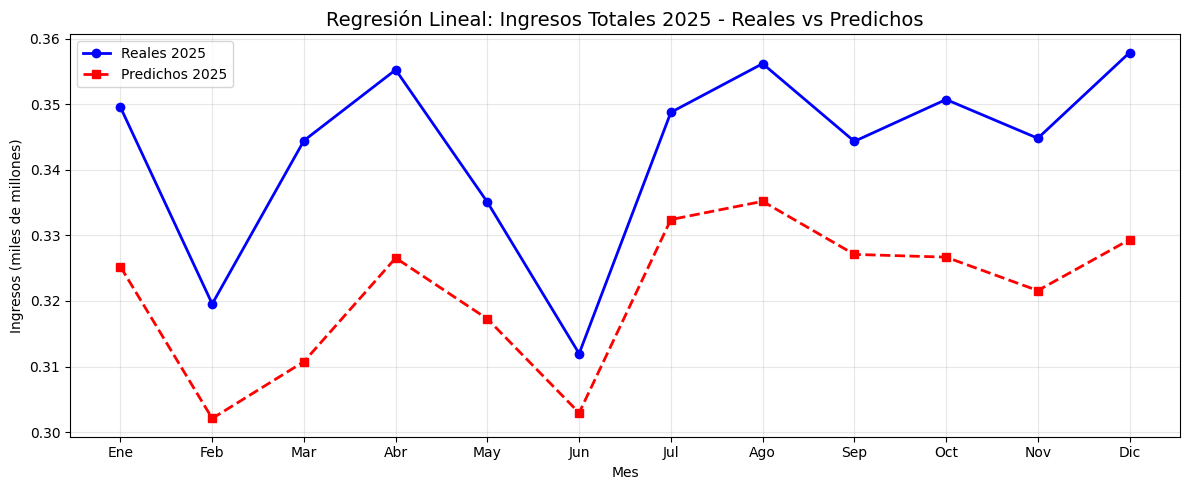

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
x_axis = range(1, 13)
meses_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

ax.plot(x_axis, y_val.values / 1e9, 'b-o', label='Reales 2025', linewidth=2)
ax.plot(x_axis, y_pred_val / 1e9, 'r--s', label='Predichos 2025', linewidth=2)
ax.set_xticks(x_axis)
ax.set_xticklabels(meses_labels)
ax.set_title('Regresión Lineal: Ingresos Totales 2025 - Reales vs Predichos', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (miles de millones)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Predicción de Ingresos Totales 2026

In [7]:
# Project features for 2026 using average monthly values from 2025 + trend
avg_2025 = df[df["Año"] == 2025]

# Create 2026 rows
meses_nombre = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

predict_2026 = pd.DataFrame()
for i, mes in enumerate(meses_nombre):
    row = {
        "Año": 2026,
        "Mes": mes,
        "Num_Mes": i + 1,
        "Mes_Indice": 72 + i,
    }
    # Use average of each month across all years for features, with trend
    month_avg = df[df["Mes"] == mes][features[:-2]].mean()
    for feat in features[:-2]:
        row[feat] = month_avg[feat]
    predict_2026 = pd.concat([predict_2026, pd.DataFrame([row])], ignore_index=True)

X_2026 = predict_2026[features]
predicciones_2026 = model.predict(X_2026)
predict_2026["Ingresos Totales Predichos"] = predicciones_2026

print("=== Predicción de Ingresos Totales 2026 ===")
for _, row in predict_2026.iterrows():
    print(f"{row['Mes']:12s}: ${row['Ingresos Totales Predichos']:>18,.0f}")

total_2026 = predict_2026["Ingresos Totales Predichos"].sum()
print(f"\n{'Total 2026':12s}: ${total_2026:>18,.0f}")

=== Predicción de Ingresos Totales 2026 ===
Enero       : $       337,698,274
Febrero     : $       314,778,170
Marzo       : $       326,114,590
Abril       : $       324,322,644
Mayo        : $       326,689,739
Junio       : $       321,797,062
Julio       : $       338,770,767
Agosto      : $       347,425,977
Septiembre  : $       332,959,338
Octubre     : $       347,100,043
Noviembre   : $       340,170,406
Diciembre   : $       344,940,468

Total 2026  : $     4,002,767,477


## 7. Visualización de Tendencia Histórica y Predicción 2026

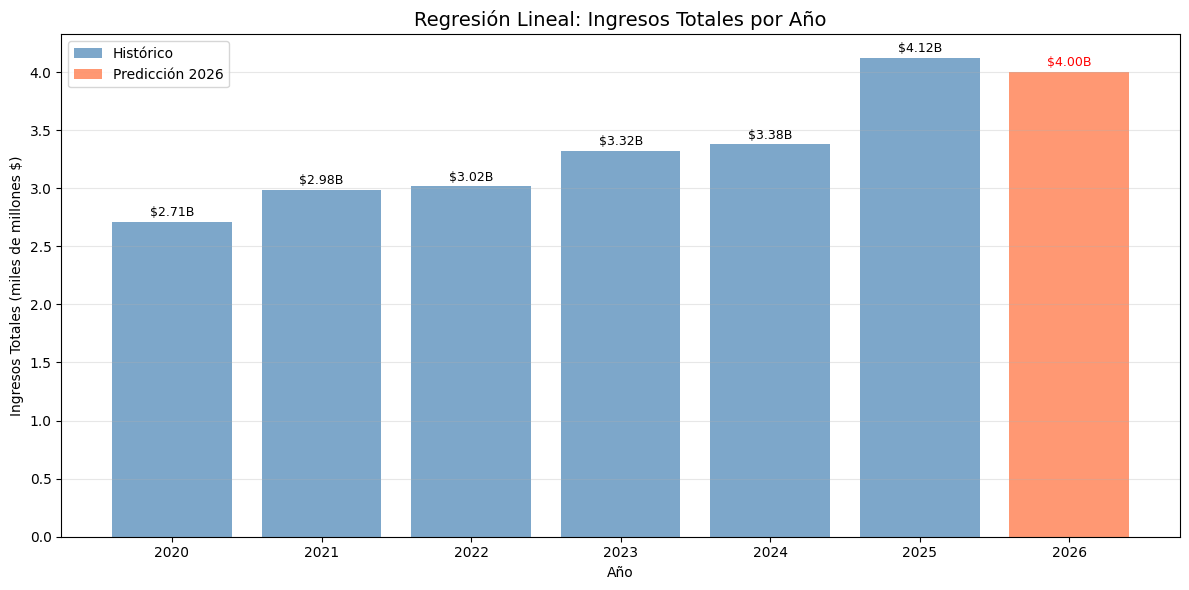

In [8]:
ingresos_anuales = df.groupby("Año")["Ingresos Totales"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(ingresos_anuales.index.astype(str), ingresos_anuales.values / 1e9, 
       color='steelblue', alpha=0.7, label='Histórico')
ax.bar("2026", total_2026 / 1e9, color='coral', alpha=0.8, label='Predicción 2026')

for i, (year, val) in enumerate(ingresos_anuales.items()):
    ax.text(i, val / 1e9 + 0.05, f'${val/1e9:.2f}B', ha='center', fontsize=9)
ax.text(len(ingresos_anuales), total_2026 / 1e9 + 0.05, f'${total_2026/1e9:.2f}B', 
        ha='center', fontsize=9, color='red')

ax.set_title('Regresión Lineal: Ingresos Totales por Año', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Ingresos Totales (miles de millones $)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
predict_2026[["Año", "Mes", "Ingresos Totales Predichos"]].to_csv("prediccion_2026.csv", index=False)
print("Predicciones exportadas a prediccion_2026.csv")

Predicciones exportadas a prediccion_2026.csv


## Conclusiones

- El modelo de Regresión Lineal captura la relación lineal entre las variables de tránsito, carga e ingresos.
- Los coeficientes permiten interpretar el impacto de cada feature en los ingresos totales.
- Limitaciones: asume relaciones puramente lineales, puede no capturar efectos no lineales complejos.